
Graph Information

=== Original ===
Nodes             : 100
Edges             : 371
Avg degree        : 7.42
Components        : 1
Largest component : 100

=== Random ===
Nodes             : 100
Edges             : 111
Avg degree        : 2.22
Components        : 8
Largest component : 92

=== Degree ===
Nodes             : 100
Edges             : 111
Avg degree        : 2.22
Components        : 45
Largest component : 56

=== PageRank ===
Nodes             : 100
Edges             : 111
Avg degree        : 2.22
Components        : 41
Largest component : 60

=== Betweenness ===
Nodes             : 100
Edges             : 111
Avg degree        : 2.22
Components        : 9
Largest component : 92

=== k-core ===
Nodes             : 100
Edges             : 370
Avg degree        : 7.40
Components        : 2
Largest component : 99

=== Weight ===
Nodes             : 100
Edges             : 111
Avg degree        : 2.22
Components        : 10
Largest component : 88

=== Local Top-k ===
Nodes    

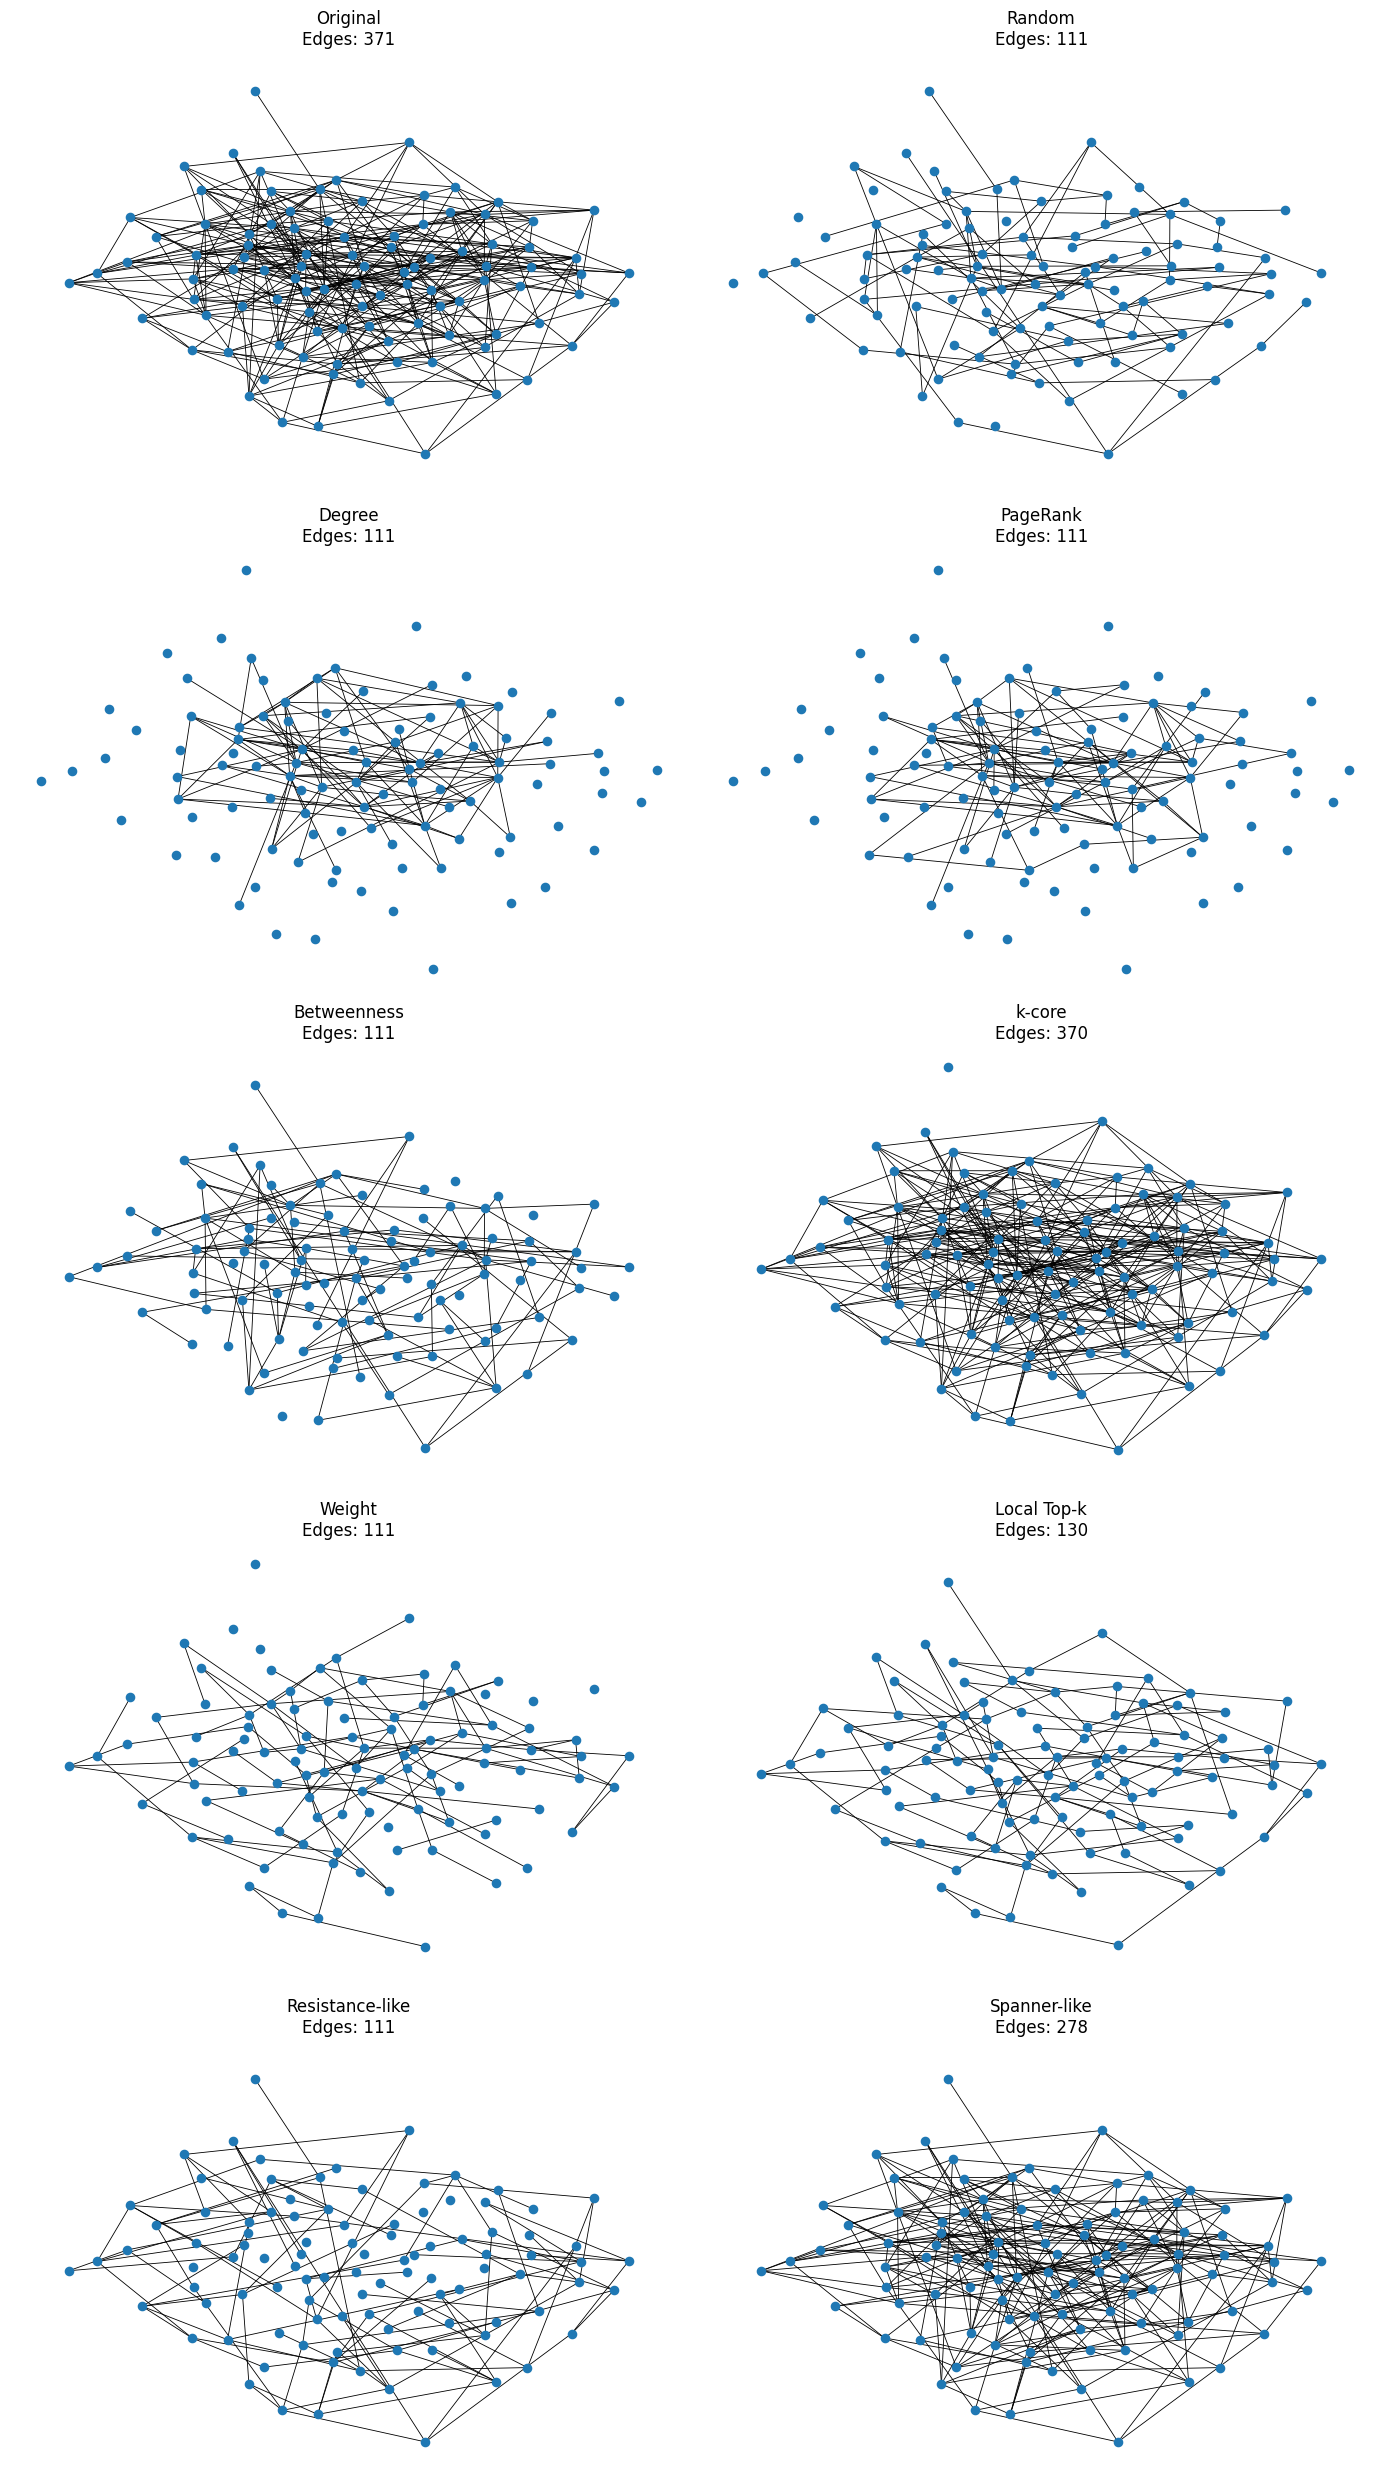

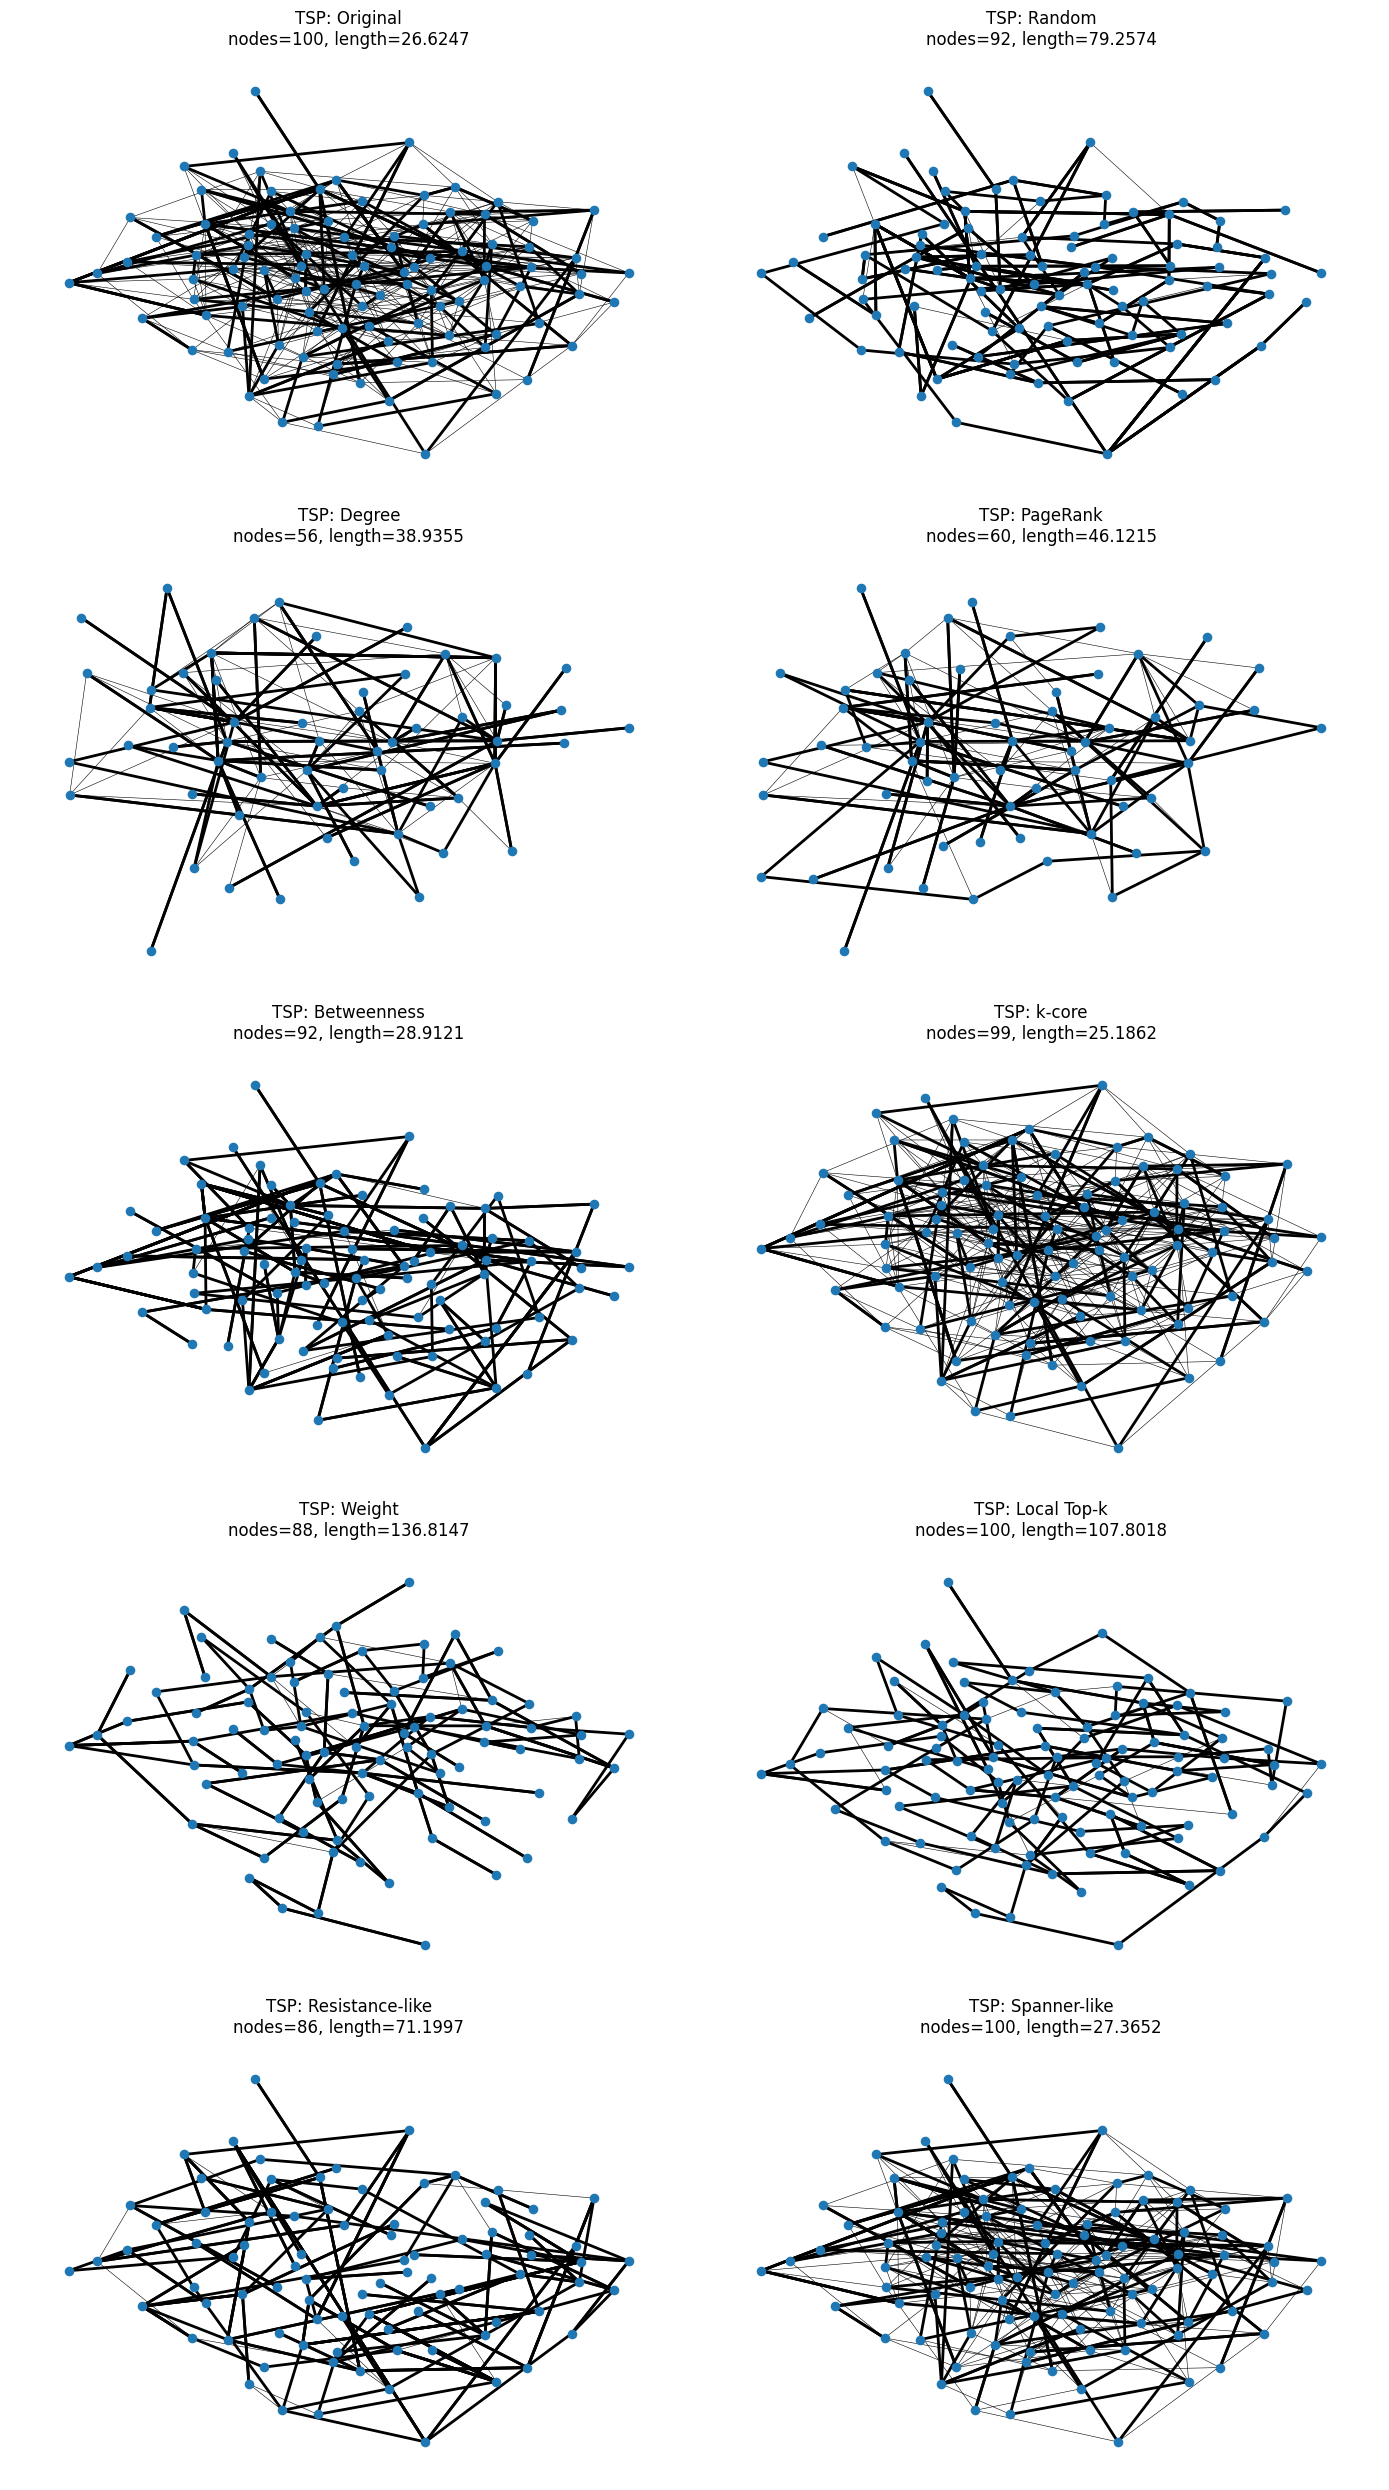

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np

from networkx.algorithms.approximation import (
    traveling_salesman_problem,
    greedy_tsp
)

# =========================
# パラメータ
# =========================
NUM_NODES = 100
EDGE_PROB = 0.08
SPARSIFY_RATIO = 0.3
SEED = 42

K_CORE = 2
LOCAL_TOP_K = 2
SPANNER_STRETCH = 2

DRAW_TSP = True

random.seed(SEED)
np.random.seed(SEED)

# =========================
# 元グラフ生成
# =========================
G = nx.erdos_renyi_graph(
    n=NUM_NODES,
    p=EDGE_PROB,
    seed=SEED
)

# 重みを付与
for u, v in G.edges():
    G[u][v]["weight"] = random.random()

# =========================
# 共通関数
# =========================
def make_graph_from_edges(G, selected_edges):
    H = nx.Graph()
    H.add_nodes_from(G.nodes())

    for u, v in selected_edges:
        if G.has_edge(u, v):
            H.add_edge(u, v, **G[u][v])
        else:
            H.add_edge(u, v, weight=1.0)

    return H


def keep_top_edges_by_score(G, edge_scores, ratio):
    edges = list(G.edges())
    num_keep = max(1, int(len(edges) * ratio))

    sorted_edges = sorted(
        edges,
        key=lambda e: edge_scores.get(tuple(sorted(e)), 0),
        reverse=True
    )

    return make_graph_from_edges(G, sorted_edges[:num_keep])


def print_graph_info(name, H):
    avg_degree = sum(dict(H.degree()).values()) / H.number_of_nodes()

    if H.number_of_edges() > 0:
        num_components = nx.number_connected_components(H)
        largest_cc_size = len(max(nx.connected_components(H), key=len))
    else:
        num_components = H.number_of_nodes()
        largest_cc_size = 1

    print(f"\n=== {name} ===")
    print(f"Nodes             : {H.number_of_nodes()}")
    print(f"Edges             : {H.number_of_edges()}")
    print(f"Avg degree        : {avg_degree:.2f}")
    print(f"Components        : {num_components}")
    print(f"Largest component : {largest_cc_size}")


# =========================
# 1. ランダム疎化
# =========================
def random_sparsification(G, ratio):
    edges = list(G.edges())
    num_keep = max(1, int(len(edges) * ratio))
    sampled_edges = random.sample(edges, num_keep)
    return make_graph_from_edges(G, sampled_edges)


# =========================
# 2. Degree-based 疎化
# =========================
def degree_based_sparsification(G, ratio):
    deg = dict(G.degree())

    edge_scores = {}
    for u, v in G.edges():
        edge_scores[tuple(sorted((u, v)))] = deg[u] + deg[v]

    return keep_top_edges_by_score(G, edge_scores, ratio)


# =========================
# 3. PageRank-based 疎化
# =========================
def pagerank_based_sparsification(G, ratio):
    pr = nx.pagerank(G)

    edge_scores = {}
    for u, v in G.edges():
        edge_scores[tuple(sorted((u, v)))] = pr[u] + pr[v]

    return keep_top_edges_by_score(G, edge_scores, ratio)


# =========================
# 4. Edge Betweenness 疎化
# =========================
def edge_betweenness_sparsification(G, ratio):
    eb = nx.edge_betweenness_centrality(G, weight="weight")

    edge_scores = {}
    for e, score in eb.items():
        edge_scores[tuple(sorted(e))] = score

    return keep_top_edges_by_score(G, edge_scores, ratio)


# =========================
# 5. k-core 疎化
# =========================
def k_core_sparsification(G, k):
    core = nx.k_core(G, k=k)

    H = nx.Graph()
    H.add_nodes_from(G.nodes())

    for u, v in core.edges():
        H.add_edge(u, v, **G[u][v])

    return H


# =========================
# 6. Weight Threshold 疎化
# =========================
def weight_threshold_sparsification(G, ratio):
    edges = list(G.edges(data=True))
    num_keep = max(1, int(len(edges) * ratio))

    sorted_edges = sorted(
        edges,
        key=lambda x: x[2].get("weight", 0),
        reverse=True
    )

    selected_edges = [(u, v) for u, v, _ in sorted_edges[:num_keep]]

    return make_graph_from_edges(G, selected_edges)


# =========================
# 7. Local Top-k 疎化
# =========================
def local_top_k_sparsification(G, k):
    selected_edges = set()

    for node in G.nodes():
        neighbors = list(G.neighbors(node))

        scored_neighbors = []
        for nbr in neighbors:
            score = G[node][nbr].get("weight", 1.0)
            scored_neighbors.append((nbr, score))

        scored_neighbors.sort(key=lambda x: x[1], reverse=True)

        for nbr, _ in scored_neighbors[:k]:
            selected_edges.add(tuple(sorted((node, nbr))))

    return make_graph_from_edges(G, list(selected_edges))


# =========================
# 8. Effective Resistance 近似疎化
# =========================
def effective_resistance_like_sparsification(G, ratio):
    deg = dict(G.degree())

    edge_scores = {}
    for u, v in G.edges():
        score = 1 / max(1, deg[u]) + 1 / max(1, deg[v])
        edge_scores[tuple(sorted((u, v)))] = score

    return keep_top_edges_by_score(G, edge_scores, ratio)


# =========================
# 9. Spanner風 疎化
# =========================
def spanner_like_sparsification(G, stretch=2):
    H = nx.Graph()
    H.add_nodes_from(G.nodes())

    edges = list(G.edges(data=True))
    random.shuffle(edges)

    for u, v, data in edges:
        if not nx.has_path(H, u, v):
            H.add_edge(u, v, **data)
        else:
            try:
                dist = nx.shortest_path_length(H, u, v, weight="weight")
                direct_weight = data.get("weight", 1.0)

                if dist > stretch * direct_weight:
                    H.add_edge(u, v, **data)

            except nx.NetworkXNoPath:
                H.add_edge(u, v, **data)

    return H


# =========================
# TSP処理
# =========================
def get_largest_connected_subgraph(H):
    if H.number_of_edges() == 0:
        return None

    if nx.is_connected(H):
        return H.copy()

    largest_cc = max(nx.connected_components(H), key=len)
    return H.subgraph(largest_cc).copy()


def compute_cycle_length(H, cycle):
    total = 0.0

    for u, v in zip(cycle[:-1], cycle[1:]):
        try:
            total += nx.shortest_path_length(
                H,
                source=u,
                target=v,
                weight="weight"
            )
        except nx.NetworkXNoPath:
            return None

    return total


def solve_tsp_for_graph(name, H):
    T = get_largest_connected_subgraph(H)

    if T is None:
        return None

    if T.number_of_nodes() < 3:
        return None

    try:
        cycle = traveling_salesman_problem(
            T,
            weight="weight",
            cycle=True,
            method=greedy_tsp
        )

        length = compute_cycle_length(T, cycle)

        return {
            "name": name,
            "nodes": T.number_of_nodes(),
            "edges": T.number_of_edges(),
            "components": nx.number_connected_components(H),
            "used_largest_component": not nx.is_connected(H),
            "tsp_length": length,
            "cycle": cycle,
            "subgraph": T
        }

    except Exception as e:
        print(f"[TSP failed] {name}: {e}")
        return None


# =========================
# 疎化実行
# =========================
graphs = {}

graphs["Original"] = G
graphs["Random"] = random_sparsification(G, SPARSIFY_RATIO)
graphs["Degree"] = degree_based_sparsification(G, SPARSIFY_RATIO)
graphs["PageRank"] = pagerank_based_sparsification(G, SPARSIFY_RATIO)
graphs["Betweenness"] = edge_betweenness_sparsification(G, SPARSIFY_RATIO)
graphs["k-core"] = k_core_sparsification(G, K_CORE)
graphs["Weight"] = weight_threshold_sparsification(G, SPARSIFY_RATIO)
graphs["Local Top-k"] = local_top_k_sparsification(G, LOCAL_TOP_K)
graphs["Resistance-like"] = effective_resistance_like_sparsification(G, SPARSIFY_RATIO)
graphs["Spanner-like"] = spanner_like_sparsification(G, SPANNER_STRETCH)

# =========================
# グラフ情報表示
# =========================
print("\n==============================")
print("Graph Information")
print("==============================")

for name, H in graphs.items():
    print_graph_info(name, H)

# =========================
# 疎化比較表
# =========================
print("\n==============================")
print("Sparsification Summary")
print("==============================")

for name, H in graphs.items():
    edge_ratio = H.number_of_edges() / G.number_of_edges()

    print(
        f"{name:16s} "
        f"edges={H.number_of_edges():4d} "
        f"edge_ratio={edge_ratio:.2f}"
    )

# =========================
# TSP実行
# =========================
print("\n==============================")
print("TSP Results")
print("==============================")

tsp_results = {}

for name, H in graphs.items():
    result = solve_tsp_for_graph(name, H)
    tsp_results[name] = result

    if result is None:
        print(f"{name:16s} : TSP failed or too small")
    else:
        mark = "largest component" if result["used_largest_component"] else "all nodes"

        print(
            f"{name:16s} "
            f"nodes={result['nodes']:3d} "
            f"edges={result['edges']:4d} "
            f"length={result['tsp_length']:.4f} "
            f"components={result['components']:3d} "
            f"used={mark}"
        )

# =========================
# グラフ描画
# =========================
pos = nx.spring_layout(G, seed=SEED)

num_graphs = len(graphs)
cols = 2
rows = int(np.ceil(num_graphs / cols))

fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 5))
axes = axes.flatten()

for ax, (name, H) in zip(axes, graphs.items()):
    nx.draw(
        H,
        pos,
        ax=ax,
        node_size=35,
        width=0.6,
        with_labels=False
    )

    ax.set_title(
        f"{name}\n"
        f"Edges: {H.number_of_edges()}"
    )

for i in range(len(graphs), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

# =========================
# TSP経路描画
# =========================
if DRAW_TSP:
    valid_tsp_results = {
        name: result
        for name, result in tsp_results.items()
        if result is not None
    }

    num_tsp = len(valid_tsp_results)

    if num_tsp > 0:
        cols = 2
        rows = int(np.ceil(num_tsp / cols))

        fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 5))

        if num_tsp == 1:
            axes = np.array([axes])

        axes = axes.flatten()

        for ax, (name, result) in zip(axes, valid_tsp_results.items()):
            T = result["subgraph"]
            cycle = result["cycle"]

            tsp_edges = []
            for u, v in zip(cycle[:-1], cycle[1:]):
                path = nx.shortest_path(T, u, v, weight="weight")
                path_edges = list(zip(path[:-1], path[1:]))
                tsp_edges.extend(path_edges)

            nx.draw(
                T,
                pos,
                ax=ax,
                node_size=35,
                width=0.4,
                with_labels=False
            )

            nx.draw_networkx_edges(
                T,
                pos,
                edgelist=tsp_edges,
                ax=ax,
                width=2.0
            )

            ax.set_title(
                f"TSP: {name}\n"
                f"nodes={result['nodes']}, "
                f"length={result['tsp_length']:.4f}"
            )

        for i in range(num_tsp, len(axes)):
            axes[i].axis("off")

        plt.tight_layout()
        plt.show()